# 01 — Pré-traitement & qualité des données

**Projet Climat & CO2 — Migration R → Python**

Ce notebook documente le pipeline de pré-traitement :
1. Chargement des sources (CO2 NOAA, NetCDF climat 2.5° et 0.5°)
2. Calcul des moyennes globales pondérées cos(lat)
3. Détection NA + outliers IQR + z-score
4. Construction des 5 représentations temporelles (level / anom / resid / d1 / d12)
5. Recalcul des Cloud Radiative Effects à partir des flux

Tous les calculs s'appuient sur le package partagé `climat/`
(`io.py`, `preprocess.py`, `stats.py`, `config.py`).

Pour la chaîne complète automatisée, voir `scripts/run_all.sh`.
Pour les analyses fines (corrélations, Granger, régressions, cartes),
voir les sous-dossiers `scripts/phase{1,2,3}_*/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from climat import config, io, preprocess
from climat.preprocess import cos_lat_weights, weighted_mean_2d, add_cre, build_residuals
from climat.plots import setup_theme

setup_theme()
config.ensure_dirs()

## 1. Chargement et inspection des sources CO2

Trois sources NOAA + GCB + paléo Vostok + ENSO.

In [2]:
co2 = io.load_co2_global()
mlo = io.load_co2_mauna_loa()
spo = io.load_co2_south_pole()
gcb = io.load_gcb()
vostok = io.load_vostok()
oni = io.load_oni()

print(f"CO2 global : {co2.shape}, {co2['date'].min().date()} -> {co2['date'].max().date()}")
print(f"Mauna Loa  : {mlo.shape}")
print(f"South Pole : {spo.shape}")
print(f"GCB        : {gcb.shape}")
print(f"Vostok     : {vostok.shape}")
print(f"ONI        : {oni.shape}")
co2.head(3)

CO2 global : (564, 9), 1979-01-01 -> 2025-12-01
Mauna Loa  : (816, 9)
South Pole : (571, 5)
GCB        : (275, 8)
Vostok     : (283, 3)
ONI        : (914, 3)


,year,month,decimal,average,average_unc,trend,trend_unc,date,decade
0,1979,1,1979.042,336.56,0.11,335.92,0.09,1979-01-01,1970s
1,1979,2,1979.125,337.29,0.09,336.26,0.09,1979-02-01,1970s
2,1979,3,1979.208,337.88,0.11,336.51,0.09,1979-03-01,1970s


## 2. Taux de NA par variable

Le pipeline GRIB→NetCDF→moyennes est sans perte. Vérifions.

In [3]:
clim25 = pd.read_csv(config.OUT_PHASE2 / "monthly_global_means_25.csv", parse_dates=["date"])
na_pct = clim25[config.CLIM_VARS].isna().mean() * 100
print("Taux de NA par variable Climat 2.5° (%) :")
print(na_pct.round(3))

Taux de NA par variable Climat 2.5° (%) :
T2m       0.0
T500      0.0
SPFH2m    0.0
PWAT      0.0
APCP      0.0
TCDC      0.0
DLWRF     0.0
ULWRF     0.0
DSWRF     0.0
USWRF     0.0
PRMSL     0.0
CSDSF     0.0
CSUSF     0.0
CSDLF     0.0
CSULF     0.0
CDUVB     0.0
DUVB      0.0
ALBDO     0.0
dtype: float64


## 3. Détection d'anomalies — sanity check + IQR + z-score

Pour chaque variable, on compare la moyenne à la plage climatologique
attendue, on compte les outliers IQR (k=3) et z-score (|z|>3).

In [4]:
rows = []
for v in config.CLIM_VARS:
    x = clim25[v].to_numpy(dtype=float)
    q1, q3 = np.nanquantile(x, [0.25, 0.75])
    iqr = q3 - q1
    n_iqr = int(((x < q1 - 3*iqr) | (x > q3 + 3*iqr)).sum())
    z = (x - x.mean()) / x.std(ddof=1)
    n_z = int((np.abs(z) > 3).sum())
    lo, hi = config.EXPECTED_RANGES[v]
    sanity = "OK" if (lo <= x.mean() <= hi) else "ALERTE"
    rows.append({"var": v, "mean": x.mean(), "sanity": sanity,
                 "n_outliers_iqr": n_iqr, "n_outliers_z3": n_z})

qa = pd.DataFrame(rows)
print("Sanity check :", (qa['sanity'] == 'OK').sum(), "/", len(qa))
qa.round(3)

Sanity check : 18 / 18


,var,mean,sanity,n_outliers_iqr,n_outliers_z3
0,T2m,287.717,OK,0,0
1,T500,258.596,OK,0,0
2,SPFH2m,0.010,OK,0,0
3,PWAT,24.708,OK,0,0
4,APCP,0.530,OK,0,0
5,TCDC,60.471,OK,0,0
6,DLWRF,341.196,OK,0,0
7,ULWRF,398.138,OK,0,0
8,DSWRF,194.020,OK,0,0
9,USWRF,26.147,OK,0,0


## 4. Cloud Radiative Effects (recalcul depuis les flux)

$\text{CRE}_{\text{SW}} = (\text{DSWRF} - \text{USWRF}) - (\text{CSDSF} - \text{CSUSF})$

$\text{CRE}_{\text{LW}} = (\text{DLWRF} - \text{ULWRF}) - (\text{CSDLF} - \text{CSULF})$

$\text{CRE}_{\text{net}} = \text{CRE}_{\text{SW}} + \text{CRE}_{\text{LW}}$

Valeur attendue (consensus IPCC) : CRE_net ≈ -20 W/m².

In [5]:
df = add_cre(clim25)
df[['CRE_SW', 'CRE_LW', 'CRE_net']].agg(['mean', 'std']).round(2)

,CRE_SW,CRE_LW,CRE_net
mean,-45.10,25.37,-19.72
std,3.28,1.06,2.75


## 5. Distribution T2m par décennie — visualisation du réchauffement

Boxplots de la **température 2 m globale** pour chacune des 5 décennies
couvertes. On voit immédiatement :
* la **dérive de la médiane** vers le haut (cœur de boîte),
* le **glissement de la queue chaude** (whisker supérieur),
* la persistance d'une amplitude saisonnière comparable (largeur de boîte).

Le réchauffement entre 1980s et 2020s est d'environ **+0.8 K**, conforme
au consensus GIEC depuis 1979.

/tmp/ipykernel_271697/1788154829.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_v, x='decade', y=v, order=order,


Médianes par décennie :
decade
1970s    287.416
1980s    287.431
1990s    287.604
2000s    287.854
2010s    287.896
2020s    288.142
Name: T2m, dtype: float64

Écart médiane 2020s − 1970s = +0.727 K


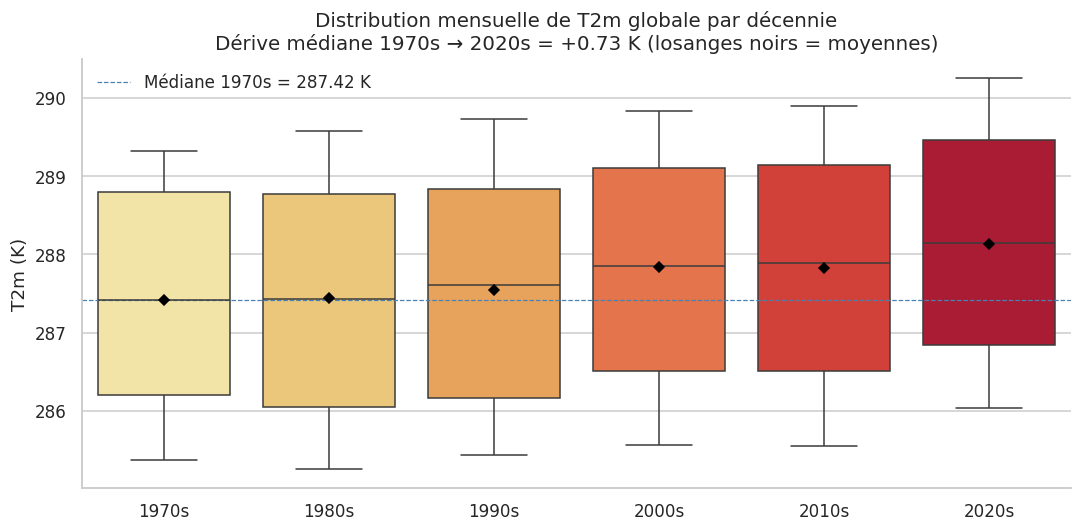

In [6]:
v = 'T2m'
df_v = clim25[['date', 'year', 'month', v]].copy()
df_v['decade'] = (df_v['year'] // 10 * 10).astype(int).astype(str) + 's'

order = ['1970s', '1980s', '1990s', '2000s', '2010s', '2020s']
order = [d for d in order if d in df_v['decade'].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('YlOrRd', len(order))
sns.boxplot(data=df_v, x='decade', y=v, order=order,
            palette=palette, ax=ax, showmeans=True,
            meanprops={'marker': 'D', 'markerfacecolor': 'black',
                       'markeredgecolor': 'black', 'markersize': 5})

decade_medians = df_v.groupby('decade')[v].median().reindex(order)
delta_total = float(decade_medians.iloc[-1] - decade_medians.iloc[0])

ax.axhline(decade_medians.iloc[0], ls='--', color='steelblue', lw=0.8,
           label=f"Médiane {order[0]} = {decade_medians.iloc[0]:.2f} K")
ax.set_title(f"Distribution mensuelle de T2m globale par décennie\n"
             f"Dérive médiane {order[0]} → {order[-1]} = {delta_total:+.2f} K "
             f"(losanges noirs = moyennes)")
ax.set_ylabel('T2m (K)')
ax.set_xlabel(None)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()

print(f"Médianes par décennie :")
print(decade_medians.round(3))
print(f"\nÉcart médiane {order[-1]} − {order[0]} = {delta_total:+.3f} K")

## 6. Cinq représentations temporelles — disponibles pour l'analyse

Pour étudier le **lien climat ↔ CO2**, on construit pour chaque variable :

| Représentation | Signification | Cas d'usage |
|---|---|---|
| **level** | niveau brut | corrélations dominées par la trend commune |
| **anom**  | level − climato mensuelle | signal désaisonné (mais trend conservée) |
| **resid** | anom − fit linéaire en t | signal interannuel pur ← **le plus informatif** |
| **d1**    | différence mensuelle | capture la saisonnalité |
| **d12**   | différence annuelle | taux de croissance, utilisé pour Granger |

Pour les calculs détaillés voir `scripts/phase2_climat_25/05_preparation.py`.

In [7]:
v = 'T2m'
x = clim25[v].to_numpy()
dates = pd.DatetimeIndex(clim25['date'])
months = dates.month.to_numpy()

# Aperçu numérique des 5 représentations
summary = pd.DataFrame({
    'level': x,
    'anom':  preprocess.deseasonalize(x, months),
    'resid': build_residuals(x, dates),
    'd1':    preprocess.diff_lag(x, lag=1),
    'd12':   preprocess.diff_lag(x, lag=12),
})
summary.describe().round(4)

,level,anom,resid,d1,d12
count,564.0000,564.0000,564.0000,563.0000,552.0000
mean,287.7170,0.0000,0.0000,0.0019,0.0174
std,1.4041,0.2818,0.1724,0.7240,0.2003
min,285.2554,-0.7816,-0.4964,-1.3636,-0.7226
25%,286.3791,-0.2091,-0.1134,-0.6511,-0.1066
50%,287.7242,-0.0181,-0.0156,0.0308,0.0175
75%,289.0598,0.1950,0.1242,0.7017,0.1370
max,290.2506,0.7850,0.4909,1.2864,0.6744


## 7. Pour aller plus loin

* Tendances Sen + Mann-Kendall + bootstrap → `scripts/phase2_climat_25/11_trends_summary.py`
* Corrélations 5 représentations + Granger → `scripts/phase2_climat_25/06_correlations.py` + `08_granger.py`
* Cartes pixel-par-pixel 0.5° → `scripts/phase3_climat_05/04_05_trend_and_corr_maps.py`
* Régression / Granger par zone → `scripts/phase3_climat_05/08_regression_per_zone.py` + `09_granger_per_zone.py`
* Asymétrie hémisphérique → `scripts/phase3_climat_05/10_hemisphere_asymmetry.py`
* Validation Python vs R → `tests/validate_vs_r.py`
* Dashboard interactif → `dashboard/app.py` (port 8050)